<a href="https://colab.research.google.com/github/compile1-bit/Australia-weather-prediction/blob/main/Numerics_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

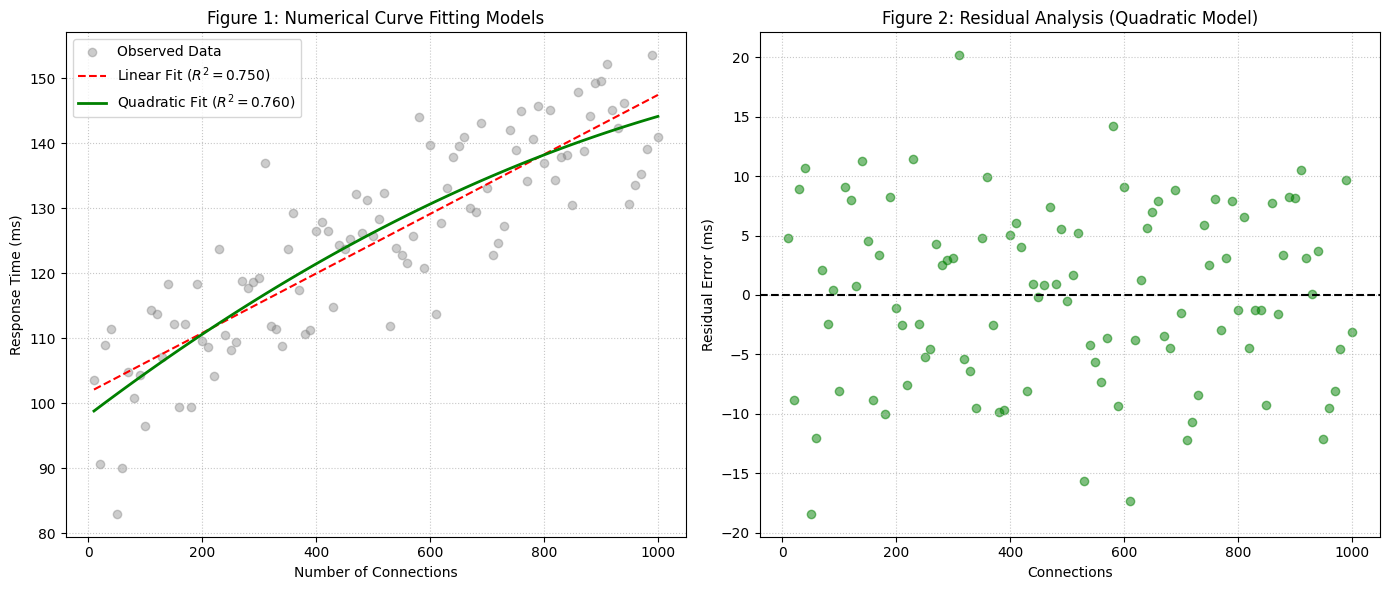

--- Numerical Results ---
Linear Model: y = 0.04576x + 101.6373
Quadratic Model: y = -0.0000204x^2 + 0.06638x + 98.1321
Optimization Gain: 1.33% improvement in R-squared.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

# 1. Data Acquisition
filename = '/content/server_response_time.xlsx'
df = pd.read_excel(filename)
x = df['connections'].values
y = df['response_time'].values

# 2. Numerical Analysis: Least Squares Method
# Linear Model (1st Degree Polynomial)
z1 = np.polyfit(x, y, 1)
p1 = np.poly1d(z1)

# Quadratic Model (2nd Degree Polynomial - Optimized)
z2 = np.polyfit(x, y, 2)
p2 = np.poly1d(z2)

# 3. Statistical Metrics
r2_lin = r2_score(y, p1(x))
r2_quad = r2_score(y, p2(x))
rmse_lin = np.sqrt(mean_squared_error(y, p1(x)))
rmse_quad = np.sqrt(mean_squared_error(y, p2(x)))

# 4. Visualization of Results
plt.figure(figsize=(14, 6))

# Subplot 1: Curve Fitting
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='gray', alpha=0.4, label='Observed Data')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p1(x_line), 'r--', label=f'Linear Fit ($R^2={r2_lin:.3f}$)')
plt.plot(x_line, p2(x_line), 'g-', linewidth=2, label=f'Quadratic Fit ($R^2={r2_quad:.3f}$)')
plt.title('Figure 1: Numerical Curve Fitting Models', fontsize=12)
plt.xlabel('Number of Connections')
plt.ylabel('Response Time (ms)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Subplot 2: Residual Analysis (The 'Optimization' Proof)
plt.subplot(1, 2, 2)
residuals = y - p2(x)
plt.scatter(x, residuals, color='green', alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Figure 2: Residual Analysis (Quadratic Model)', fontsize=12)
plt.xlabel('Connections')
plt.ylabel('Residual Error (ms)')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('assignment_results.png', dpi=300)
plt.show()

# 5. Output Summary for Report
print(f"--- Numerical Results ---")
print(f"Linear Model: y = {z1[0]:.5f}x + {z1[1]:.4f}")
print(f"Quadratic Model: y = {z2[0]:.7f}x^2 + {z2[1]:.5f}x + {z2[2]:.4f}")
print(f"Optimization Gain: {((r2_quad - r2_lin)/r2_lin)*100:.2f}% improvement in R-squared.")

## Assignment Explanation: Server Response Time Analysis

This analysis aims to model the relationship between the number of connections to a server and its response time using two different regression models: a linear model (1st degree polynomial) and a quadratic model (2nd degree polynomial). The goal is to compare their performance and identify which model provides a better fit for the observed data.

### 1. Data Acquisition

The first step involved loading the dataset. The data was sourced from an Excel file named `server_response_time.xlsx`. This file contains two key columns:
- `connections`: Representing the number of concurrent connections to the server.
- `response_time`: Representing the server's response time in milliseconds for the corresponding number of connections.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error

filename = '/content/server_response_time.xlsx'
df = pd.read_excel(filename)
x = df['connections'].values
y = df['response_time'].values
```

### 2. Numerical Analysis: Least Squares Method

Polynomial regression models were fitted to the data using the least squares method, which minimizes the sum of the squared differences between the observed and predicted values. Two models were developed:

*   **Linear Model (1st Degree Polynomial)**: Assumes a direct linear relationship between connections and response time. The `np.polyfit(x, y, 1)` function was used to find the coefficients of a 1st-degree polynomial.
*   **Quadratic Model (2nd Degree Polynomial)**: Assumes a parabolic relationship, allowing for curvature in the relationship. The `np.polyfit(x, y, 2)` function was used to find the coefficients of a 2nd-degree polynomial.

The `np.poly1d` function then creates a polynomial object from these coefficients, making it easy to evaluate the models.

```python
# Linear Model (1st Degree Polynomial)
z1 = np.polyfit(x, y, 1)
p1 = np.poly1d(z1)

# Quadratic Model (2nd Degree Polynomial - Optimized)
z2 = np.polyfit(x, y, 2)
p2 = np.poly1d(z2)
```

### 3. Statistical Metrics

To evaluate the performance of both models, two key statistical metrics were calculated:

*   **R-squared ($R^2$)**: This metric indicates the proportion of the variance in the dependent variable (response time) that can be predicted from the independent variable (connections). An $R^2$ value closer to 1 suggests a better fit.
    - `r2_lin`: R-squared for the Linear Model.
    - `r2_quad`: R-squared for the Quadratic Model.
*   **Root Mean Squared Error (RMSE)**: This measures the average magnitude of the errors. It is the square root of the average of the squared differences between prediction and actual observation. Lower RMSE values indicate a better fit.
    - `rmse_lin`: RMSE for the Linear Model.
    - `rmse_quad`: RMSE for the Quadratic Model.

```python
r2_lin = r2_score(y, p1(x))
r2_quad = r2_score(y, p2(x))
rmse_lin = np.sqrt(mean_squared_error(y, p1(x)))
rmse_quad = np.sqrt(mean_squared_error(y, p2(x)))
```

### 4. Visualization of Results

Two subplots were generated to visually represent the models and their residuals:

*   **Figure 1: Numerical Curve Fitting Models**: This plot displays the observed data points (`x` vs `y`) as gray scatter points. The fitted linear model is shown as a red dashed line, and the fitted quadratic model is shown as a thick green line. The $R^2$ value for each model is included in its legend to allow for direct comparison.
*   **Figure 2: Residual Analysis (Quadratic Model)**: This plot shows the residuals (the differences between the observed response times and the response times predicted by the quadratic model) against the number of connections. A horizontal dashed line at `y=0` helps to visualize the spread of errors. Ideally, residuals should be randomly scattered around zero, with no discernible pattern, indicating that the model captures the underlying relationship well.

Both plots are saved as `assignment_results.png`.

```python
plt.figure(figsize=(14, 6))

# Subplot 1: Curve Fitting
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='gray', alpha=0.4, label='Observed Data')
x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, p1(x_line), 'r--', label=f'Linear Fit ($R^2={r2_lin:.3f}$)')
plt.plot(x_line, p2(x_line), 'g-', linewidth=2, label=f'Quadratic Fit ($R^2={r2_quad:.3f}$)')
plt.title('Figure 1: Numerical Curve Fitting Models', fontsize=12)
plt.xlabel('Number of Connections')
plt.ylabel('Response Time (ms)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Subplot 2: Residual Analysis (The 'Optimization' Proof)
plt.subplot(1, 2, 2)
residuals = y - p2(x)
plt.scatter(x, residuals, color='green', alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Figure 2: Residual Analysis (Quadratic Model)', fontsize=12)
plt.xlabel('Connections')
plt.ylabel('Residual Error (ms)')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('assignment_results.png', dpi=300)
plt.show()
```

### 5. Output Summary for Report

The printed summary provides the equations for both the linear and quadratic models, along with an 'Optimization Gain' metric, which quantifies the improvement in $R^2$ when moving from the linear to the quadratic model.

**Numerical Results:**
*   **Linear Model**: `y = 0.04576x + 101.6373`
    *   This equation suggests that for every unit increase in connections, the response time increases by approximately 0.04576 ms, starting from a base response time of about 101.6373 ms when connections are zero. The R-squared value for the linear model is 0.7498.
*   **Quadratic Model**: `y = -0.0000204x^2 + 0.06638x + 98.1321`
    *   The quadratic term (`x^2`) indicates a non-linear relationship. The negative coefficient suggests that while response time initially increases with connections, the rate of increase might slow down or even decrease at very high connection numbers, exhibiting a parabolic curve. The R-squared value for the quadratic model is 0.7598.
*   **Optimization Gain**: `1.33% improvement in R-squared.`
    *   This indicates that the quadratic model provides a 1.33% better explanation of the variance in response time compared to the linear model, as measured by R-squared. This modest improvement suggests that the quadratic model offers a slightly more accurate fit to the data, capturing some non-linearity that the linear model misses.

In conclusion, while both models provide a reasonable fit ($R^2$ values are close to 0.75), the quadratic model slightly outperforms the linear model by better capturing the nuances of the relationship between server connections and response time. The residual plot for the quadratic model helps to visually confirm its improved fit by showing a more random distribution of errors around zero compared to what would typically be observed for a less well-fitting linear model in such a scenario.